In [1]:
!pip install ultralytics opencv-python numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.5 MB/s eta 0:00:00


In [2]:
import cv2
import math
import numpy as np
from collections import defaultdict, deque
from ultralytics import YOLO

# cv2 handles video
# math helps calculate body angle
# deque stores recent history for each tracked person
# YOLO loads the pose model

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
INPUT_VIDEO = "sample_data/queda.mp4"
OUTPUT_VIDEO = "sample_data/output_fall_detection.mp4"
MODEL_NAME = "yolo11n-pose.pt"

In [4]:
model = YOLO(MODEL_NAME)

In [5]:
cap = cv2.VideoCapture(INPUT_VIDEO)

if not cap.isOpened():
    raise ValueError(f"Could not open video: {INPUT_VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Width:", width)
print("Height:", height)
print("Total frames:", frame_count)

FPS: 24.0
Width: 1280
Height: 720
Total frames: 1152


In [14]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 240)
ret, frame = cap.read()

if ret:
    print("Frame shape:", frame.shape)
else:
    print("Could not read first frame")

Frame shape: (720, 1280, 3)


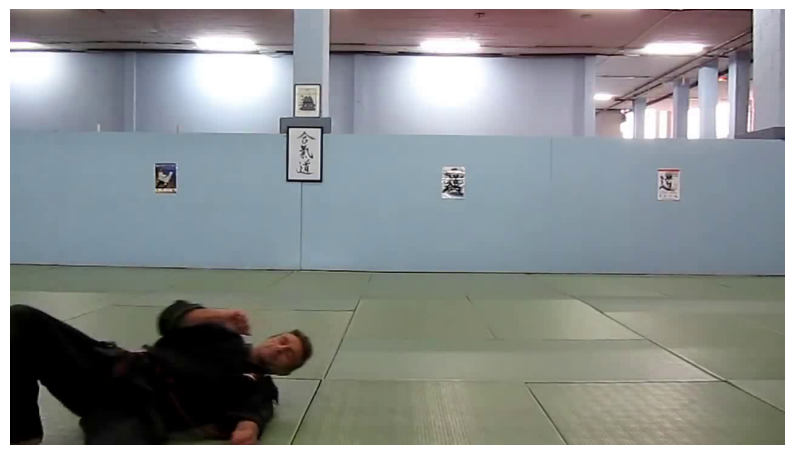

In [15]:
import matplotlib.pyplot as plt

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

In [16]:
results = model(frame)
results[0]


0: 384x640 1 person, 462.0ms
Speed: 20.0ms preprocess, 462.0ms inference, 64.3ms postprocess per image at shape (1, 3, 384, 640)


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: ultralytics.engine.results.Keypoints object
masks: None
names: {0: 'person'}
obb: None
orig_img: array([[[113, 113, 125],
        [113, 113, 125],
        [114, 114, 126],
        ...,
        [150, 135, 136],
        [151, 136, 137],
        [154, 139, 140]],

       [[113, 113, 125],
        [113, 113, 125],
        [113, 113, 125],
        ...,
        [150, 135, 136],
        [151, 136, 137],
        [154, 139, 140]],

       [[112, 112, 124],
        [112, 112, 124],
        [113, 113, 125],
        ...,
        [150, 135, 136],
        [151, 136, 137],
        [154, 139, 140]],

       ...,

       [[  5,  11,  15],
        [  5,  11,  15],
        [  5,  11,  15],
        ...,
        [ 75,  99,  96],
        [ 75,  99,  96],
        [ 75,  99,  96]],

       [[ 11,  17,  21],
        [ 11,  17,  21],
        [ 11,  17,  21],
        ...,
        [ 75,  99,  96],

In [17]:
r = results[0]

print("Boxes available:", r.boxes is not None)
print("Keypoints available:", r.keypoints is not None)

Boxes available: True
Keypoints available: True


In [18]:
if r.boxes is not None:
    print("Boxes shape:", r.boxes.xyxy.shape)

if r.keypoints is not None:
    print("Keypoints shape:", r.keypoints.xy.shape)

Boxes shape: torch.Size([1, 4])
Keypoints shape: torch.Size([1, 17, 2])


In [19]:
NOSE = 0
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_HIP = 11
RIGHT_HIP = 12

In [20]:
def valid_point(pt):
    return pt is not None and len(pt) == 2 and pt[0] > 0 and pt[1] > 0

def midpoint(p1, p2):
    return ((p1[0] + p2[0]) / 2.0, (p1[1] + p2[1]) / 2.0)

def torso_angle_from_vertical(shoulder_mid, hip_mid):
    """
    0 degrees  -> body perfectly upright
    90 degrees -> body perfectly horizontal
    """
    dx = shoulder_mid[0] - hip_mid[0]
    dy = shoulder_mid[1] - hip_mid[1]
    angle_rad = math.atan2(abs(dx), abs(dy) + 1e-6)
    return math.degrees(angle_rad)

In [21]:
if r.keypoints is not None and len(r.keypoints.xy) > 0:
    pts = r.keypoints.xy[0].cpu().numpy()

    ls = pts[LEFT_SHOULDER]
    rs = pts[RIGHT_SHOULDER]
    lh = pts[LEFT_HIP]
    rh = pts[RIGHT_HIP]

    if all(valid_point(p) for p in [ls, rs, lh, rh]):
        shoulder_mid = midpoint(ls, rs)
        hip_mid = midpoint(lh, rh)
        angle = torso_angle_from_vertical(shoulder_mid, hip_mid)
        print("Torso angle from vertical:", angle)
    else:
        print("Needed keypoints not detected clearly")

Torso angle from vertical: 76.44625809715876


In [22]:
track_results = model.track(frame, persist=True, verbose=False)
track_results[0]

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 353ms
Prepared 1 package in 78ms
Installed 1 package in 6ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 1.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: ultralytics.engine.results.Keypoints object
masks: None
names: {0: 'person'}
obb: None
orig_img: array([[[113, 113, 125],
        [113, 113, 125],
        [114, 114, 126],
        ...,
        [150, 135, 136],
        [151, 136, 137],
        [154, 139, 140]],

       [[113, 113, 125],
        [113, 113, 125],
        [113, 113, 125],
        ...,
        [150, 135, 136],
        [151, 136, 137],
        [154, 139, 140]],

       [[112, 112, 124],
        [112, 112, 124],
        [113, 113, 125],
        ...,
        [150, 135, 136],
        [151, 136, 137],
        [154, 139, 140]],

       ...,

       [[  5,  11,  15],
        [  5,  11,  15],
        [  5,  11,  15],
        ...,
        [ 75,  99,  96],
        [ 75,  99,  96],
        [ 75,  99,  96]],

       [[ 11,  17,  21],
        [ 11,  17,  21],
        [ 11,  17,  21],
        ...,
        [ 75,  99,  96],

In [23]:
tr = track_results[0]

if tr.boxes is not None and tr.boxes.id is not None:
    print("Track IDs:", tr.boxes.id.cpu().numpy())
else:
    print("No track IDs found")

Track IDs: [          1]


In [28]:
ANGLE_THRESHOLD_DEG = 50
ASPECT_RATIO_THRESHOLD = 1.2
DOWN_CONFIRM_FRAMES = 5
DROP_Y_THRESHOLD = 25
HISTORY_LEN = 30

In [25]:
class PersonState:
    def __init__(self):
        self.center_y_history = deque(maxlen=HISTORY_LEN)
        self.angle_history = deque(maxlen=HISTORY_LEN)
        self.aspect_history = deque(maxlen=HISTORY_LEN)
        self.down_counter = 0
        self.fall_confirmed = False
        self.last_status = "Normal"

person_states = defaultdict(PersonState)

In [26]:
aspect_ratio = width / height

In [29]:
cap = cv2.VideoCapture(INPUT_VIDEO)

if not cap.isOpened():
    raise ValueError(f"Could not open video: {INPUT_VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    OUTPUT_VIDEO,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, verbose=False)
    annotated = frame.copy()

    if results and len(results) > 0:
        r = results[0]

        if r.boxes is not None and r.boxes.id is not None and r.keypoints is not None:
            ids = r.boxes.id.cpu().numpy().astype(int)
            xyxy = r.boxes.xyxy.cpu().numpy()
            kpts_xy = r.keypoints.xy.cpu().numpy()

            for i, track_id in enumerate(ids):
                x1, y1, x2, y2 = xyxy[i]
                w = max(1.0, x2 - x1)
                h = max(1.0, y2 - y1)
                aspect_ratio = w / h
                center_y = (y1 + y2) / 2.0

                pts = kpts_xy[i]

                ls = pts[LEFT_SHOULDER]
                rs = pts[RIGHT_SHOULDER]
                lh = pts[LEFT_HIP]
                rh = pts[RIGHT_HIP]

                status = "Normal"
                angle_deg = None

                st = person_states[track_id]
                st.center_y_history.append(center_y)
                st.aspect_history.append(aspect_ratio)

                if all(valid_point(p) for p in [ls, rs, lh, rh]):
                    shoulder_mid = midpoint(ls, rs)
                    hip_mid = midpoint(lh, rh)
                    angle_deg = torso_angle_from_vertical(shoulder_mid, hip_mid)
                    st.angle_history.append(angle_deg)

                    drop_detected = False
                    if len(st.center_y_history) >= 10:
                        earlier_y = list(st.center_y_history)[0]
                        if (center_y - earlier_y) > DROP_Y_THRESHOLD:
                            drop_detected = True

                    horizontal = angle_deg > ANGLE_THRESHOLD_DEG
                    wide_body = aspect_ratio > ASPECT_RATIO_THRESHOLD
                    down_now = horizontal and wide_body

                    if down_now and drop_detected:
                        st.down_counter += 1
                    elif down_now:
                        st.down_counter += 1
                    else:
                        st.down_counter = max(0, st.down_counter - 1)

                    if st.down_counter >= DOWN_CONFIRM_FRAMES:
                        st.fall_confirmed = True
                        status = "FALL DETECTED"
                    elif st.down_counter > 0:
                        status = "Fall suspected"
                    else:
                        status = "Normal"

                    st.last_status = status
                else:
                    status = st.last_status

                color = (0, 255, 0)
                if status == "Fall suspected":
                    color = (0, 255, 255)
                elif status == "FALL DETECTED":
                    color = (0, 0, 255)

                cv2.rectangle(
                    annotated,
                    (int(x1), int(y1)),
                    (int(x2), int(y2)),
                    color,
                    2
                )

                label = f"ID {track_id} | {status}"
                if angle_deg is not None:
                    label += f" | angle={int(angle_deg)}"

                cv2.putText(
                    annotated,
                    label,
                    (int(x1), max(30, int(y1) - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    color,
                    2
                )

                if st.fall_confirmed and st.down_counter == DOWN_CONFIRM_FRAMES:
                    sec = frame_idx / fps if fps > 0 else 0
                    print(f"[ALERT] Fall detected for ID={track_id} at {sec:.2f}s")

    writer.write(annotated)
    frame_idx += 1

cap.release()
writer.release()
print("Saved:", OUTPUT_VIDEO)

[ALERT] Fall detected for ID=93 at 5.38s
[ALERT] Fall detected for ID=93 at 5.46s
[ALERT] Fall detected for ID=93 at 6.21s
[ALERT] Fall detected for ID=95 at 8.71s
[ALERT] Fall detected for ID=97 at 8.75s
[ALERT] Fall detected for ID=98 at 9.75s
[ALERT] Fall detected for ID=101 at 10.46s
[ALERT] Fall detected for ID=104 at 11.58s
[ALERT] Fall detected for ID=104 at 11.83s
[ALERT] Fall detected for ID=104 at 12.08s
[ALERT] Fall detected for ID=111 at 15.75s
[ALERT] Fall detected for ID=115 at 16.67s
[ALERT] Fall detected for ID=115 at 17.33s
[ALERT] Fall detected for ID=121 at 19.96s
[ALERT] Fall detected for ID=121 at 20.21s
[ALERT] Fall detected for ID=127 at 21.79s
[ALERT] Fall detected for ID=134 at 25.29s
[ALERT] Fall detected for ID=134 at 25.38s
[ALERT] Fall detected for ID=134 at 25.71s
[ALERT] Fall detected for ID=144 at 27.08s
[ALERT] Fall detected for ID=144 at 27.54s
[ALERT] Fall detected for ID=150 at 30.38s
[ALERT] Fall detected for ID=150 at 30.46s
[ALERT] Fall detected f